# Task 1: Collaborative Filtering

## Objective

This task compares two collaborative filtering approaches using the same user-item interaction dataset:

1. Memory-based collaborative filtering
2. Model-based collaborative filtering using matrix factorization



## 1. Dataset Selection

### Dataset: MovieLens

MovieLens is a suitable dataset for this task because it contains user-item interactions in the form of movie ratings.

The dataset provides:

- User IDs
- Movie IDs
- Explicit ratings
- Timestamps

This allows us to construct a user-item interaction matrix and apply both memory-based collaborative filtering and matrix factorization using the same data.

In [53]:
import pandas as pd
ratings=pd.read_csv("data/ml-100k/u.data", sep="\t", names=["user_id","item_id","ratings","timestamp"])

ratings.head()

,user_id,item_id,ratings,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [54]:
print("Number Of ratings:- ", len(ratings))
print("Number of Users:- ",ratings["user_id"].nunique())
print("Number of movies:", ratings["item_id"].nunique())
print("Rating range:", ratings["ratings"].min(), "to", ratings["ratings"].max())

Number Of ratings:-  100000
Number of Users:-  943
Number of movies: 1682
Rating range: 1 to 5


## BIG PROBLEM :-  

#### If we split the data based on chronological order, then some of the users and movies might only be present in test set, Hence We cannot predict the ratings for unseen users and unseen movies

### the data is split separately for each user. For each user, 80% of their interactions are used for training and 20% for testing.


In [55]:
from sklearn.model_selection import train_test_split

train_parts = []
test_parts = []

for user_id, user_data in ratings.groupby("user_id"):
    user_train, user_test = train_test_split(
        user_data,
        test_size=0.2,
        random_state=42
    )

    train_parts.append(user_train)
    test_parts.append(user_test)

train = pd.concat(train_parts).reset_index(drop=True)
test = pd.concat(test_parts).reset_index(drop=True)

print("Training interactions:", len(train))
print("Test interactions:", len(test))

Training interactions: 79619
Test interactions: 20381


In [56]:
train_users = set(train["user_id"])
train_items = set(train["item_id"])

test_users_unseen = test[~test["user_id"].isin(train_users)]
test_items_unseen = test[~test["item_id"].isin(train_items)]

print("Test interactions with unseen users:", len(test_users_unseen))
print("Test interactions with unseen movies:", len(test_items_unseen))


#But we may still have some unseen movies, because a movie might have been rated by only one user and that rating could have landed in the test set.

Test interactions with unseen users: 0
Test interactions with unseen movies: 35


In [ ]:
# EXCLUDING THESE 35 Movies

test = test[test["item_id"].isin(train_items)].copy()

print("Training interactions:", len(train))
print("Test interactions:", len(test))
print("Unseen users:", len(test[~test["user_id"].isin(train_users)]))
print("Unseen movies:", len(test[~test["item_id"].isin(train_items)]))

Training interactions: 79619
Test interactions: 20346
Unseen users: 0
Unseen movies: 0


### Handling unseen items

After splitting the data by user, 35 test interactions corresponded to movies that were not present in the training set.

Since both collaborative filtering approaches require information about an item from the training data, these interactions cannot be evaluated meaningfully in this comparison. Therefore, they are excluded from the test set.

After filtering, every user and movie appearing in the test set is also present in the training set.

WE need to convert
 
|user_id  |  item_id |   rating|
|---------|----------|---------|
|196      |  242     |   3     |  
|186      |  302     |   3     |
|22       |  377     |   1     |
...
            to

|          |   Movie 1 |  Movie 2 |  Movie 3 |  Movie 4|
|----------|-----------|----------|----------|---------|
|User 1    |      5    |     0    |     3    |     0   |
|User 2    |      0    |     4    |     0    |     2   |
|User 3    |      3    |     0    |     5    |     0   |
|...

0= user hasn't rated that movie

This matrix is foundation for both the approaches
### Memory-based CF:-  User → compare users → find similar users → recommend movies

### Matrix Factorization:- User-item matrix → learn latent user/item vectors → predict ratings

In [58]:
user_item_matrix = train.pivot(    # Using .pivot to convert Dataframe into 2D matrix
    index="user_id",
    columns="item_id",
    values="ratings"
)

print("Matrix shape:", user_item_matrix.shape)
user_item_matrix.head()

Matrix shape: (943, 1650)


item_id,1,2,3,4,5,6,7,8,9,10,...,1669,1670,1671,1672,1674,1675,1678,1679,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,4.0,NaN,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##  Understanding Sparsity

Let's calculate how much of this matrix is actually filled.


In [60]:
total_entries = user_item_matrix.size                  # Total Entries=  Total Users(rows) * Total Items(columns)
rated_entries = user_item_matrix.notna().sum().sum()   # user_item_matrix.notna() :-  Creates a boolean grid where non-empty cells (ratings) become True and missing cells (NaN) become False.
                                                       #First .sum(): Sums True values along each column, giving a Series of non-null counts per item.
                                                       #Second .sum(): Adds those column totals together to get the total number of actual ratings across the entire matrix.

sparsity = 1 - (rated_entries / total_entries)

print("Total possible entries:", total_entries)
print("Actual ratings:", rated_entries)
print("Sparsity:", sparsity)

Total possible entries: 1555950
Actual ratings: 79619
Sparsity: 0.9488293325621003


# STARTING WITH MEMORY-BASED COLLABORATIVE FILTERING:--

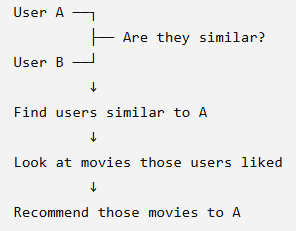

But there is a slight issue, we cannot convert NAN to 0 and find cosine similarities because NAN are not ratings, hence We will only consider those movies which both the users have rated than we will calculate cosine similarity between them


# TEST RUN ON ONLY TWO USERS

### FIND COMMON MOVIES AMOUNG THEM AND CALCULATE THERE COSINE SIMILARITY

In [61]:
user1 = user_item_matrix.loc[1]
user2 = user_item_matrix.loc[2]

common_movies = user1.notna() & user2.notna()

print("Common movies:", common_movies.sum())

print("\nUser 1 ratings:")
print(user1[common_movies])

print("\nUser 2 ratings:")
print(user2[common_movies])

Common movies: 13

User 1 ratings:
item_id
10     3.0
13     5.0
14     5.0
19     5.0
50     5.0
111    5.0
127    5.0
242    5.0
251    4.0
255    2.0
257    4.0
269    5.0
272    3.0
Name: 1, dtype: float64

User 2 ratings:
item_id
10     2.0
13     4.0
14     4.0
19     3.0
50     5.0
111    4.0
127    5.0
242    5.0
251    5.0
255    4.0
257    4.0
269    4.0
272    5.0
Name: 2, dtype: float64


In [62]:
from sklearn.metrics.pairwise import cosine_similarity

user1_ratings = user1[common_movies].values.reshape(1, -1)
user2_ratings = user2[common_movies].values.reshape(1, -1)

similarity = cosine_similarity(user1_ratings, user2_ratings)[0][0]

print("Cosine similarity:", similarity)

Cosine similarity: 0.9639246252107532


# SCALING UP

1) MINIMUM OVERLAPP RULE:- Setting Up minimum number of common movies between two users as 5 for us to consider there cosine similarity



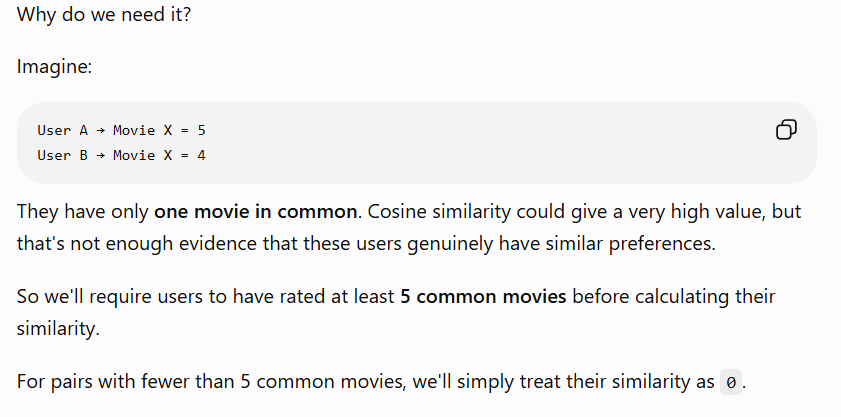

In [63]:
# NOW LETS BUILD THE FULL USER-USER Similarity Matrix

import numpy as np

MIN_COMMON_RATINGS = 20  # Was previously 5 but changed to 20

def user_similarity(user_a, user_b):                # Function to calculate similarities between two users
    common = user_a.notna() & user_b.notna()

    if common.sum() < MIN_COMMON_RATINGS:
        return 0.0

    a = user_a[common].values.reshape(1, -1)
    b = user_b[common].values.reshape(1, -1)

    return cosine_similarity(a, b)[0][0]

#--------------------------------------------------------------------#
    
user_ids = user_item_matrix.index
n_users = len(user_ids)

similarity_matrix = np.zeros((n_users, n_users))

for i in range(n_users):
    for j in range(i, n_users):
        similarity = user_similarity(
            user_item_matrix.iloc[i],
            user_item_matrix.iloc[j]
        )

        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

similarity_matrix = pd.DataFrame(
    similarity_matrix,
    index=user_ids,
    columns=user_ids
)

similarity_matrix.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.0,0.0,0.0,0.950521,0.948214,0.937979,0.968528,0.0,0.970528,...,0.949931,0.0,0.965449,0.0,0.92221,0.0,0.946922,0.0,0.0,0.939305
2,0.000000,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.955406,0.0,0.00000,0.0,0.000000,0.0,0.0,0.000000
3,0.000000,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.000000
4,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.000000
5,0.950521,0.0,0.0,0.0,1.000000,0.925124,0.904787,0.000000,0.0,0.953312,...,0.922802,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.911193



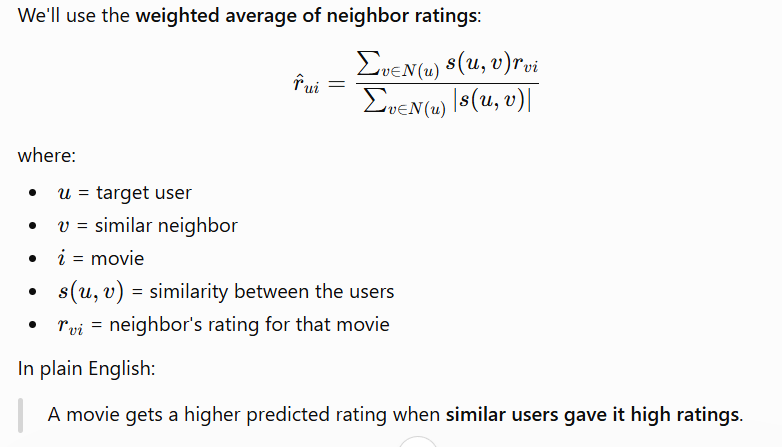

# Prediction AND Evaulation Of Memory Based CF

### Step 1 -- Building top 10 neighbors for every user and storing it

In [81]:
K = 10

all_neighbors = {}

for user_id in similarity_matrix.index:
    similarities = similarity_matrix.loc[user_id].drop(user_id)

    neighbors = (
        similarities[similarities > 0]
        .sort_values(ascending=False)
        .head(K)
    )

    all_neighbors[user_id] = neighbors

print("Users processed:", len(all_neighbors))

Users processed: 943


### Step 2 -- Predict Every test rating

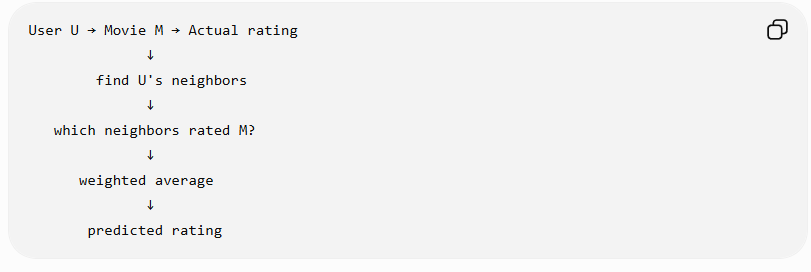

In [87]:
memory_predictions = []
memory_actuals = []
evaluated_cases = []

for _, row in test.iterrows():
    user_id = row["user_id"]
    item_id = row["item_id"]

    neighbors = all_neighbors[user_id]

    # Ratings for this movie from the user's neighbors
    ratings = user_item_matrix.loc[neighbors.index, item_id].dropna()

    # No neighbor rated this movie
    if len(ratings) == 0:
        continue

    # Similarities of only those neighbors
    weights = neighbors.loc[ratings.index]

    # Similarity-weighted prediction
    prediction = (ratings * weights).sum() / weights.sum()

    memory_predictions.append(prediction)
    memory_actuals.append(row["ratings"])

    # Save the test interaction that was successfully predicted
    evaluated_cases.append((user_id, item_id))

print("Predictions made:", len(memory_predictions))
print("Test cases:", len(test))
print("Coverage:", len(memory_predictions) / len(test))

Predictions made: 13596
Test cases: 20346
Coverage: 0.6682394573872014


1) MAE → average absolute difference between actual and predicted rating.
2) RMSE → similar, but penalizes large errors more heavily.
3) Coverage → percentage of test cases for which our recommender could produce a prediction.

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.7465220649795521
RMSE: 0.952546470821247


## BUILDING A BASE LINE TO COMPARE MEMORY BASED CF

###  Idea:- Give same rating to all the predictions (Global Mean)

In [89]:
global_mean = train["ratings"].mean()

baseline_predictions = [global_mean] * len(test)

baseline_mae = mean_absolute_error(
    test["ratings"],
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["ratings"],
        baseline_predictions
    )
)

print("Global mean:", global_mean)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Global mean: 3.529986560996747
Baseline MAE: 0.9435235015549522
Baseline RMSE: 1.1243218686369771


In [90]:
# Baseline for Covered cases

baseline_predictions_covered = [global_mean] * len(actuals)

baseline_mae_covered = mean_absolute_error(
    actuals,
    baseline_predictions_covered
)

baseline_rmse_covered = np.sqrt(
    mean_squared_error(
        actuals,
        baseline_predictions_covered
    )
)

print("Baseline MAE (same covered cases):", baseline_mae_covered)
print("Baseline RMSE (same covered cases):", baseline_rmse_covered)

Baseline MAE (same covered cases): 0.9450551291064234
Baseline RMSE (same covered cases): 1.1240559999796453


                    MovieLens ratings
                           │
                           ↓
                    Train / Test split
                           │
                           ↓
                  User-Item Matrix
                           │
                           ↓
                      Sparsity
                           │
                           ↓
              Compare users using cosine
                           │
                           ↓
               User-User Similarity Matrix
                           │
                           ↓
                 Pick target user
                  (example: User 1)
                           │
                           ↓
                  Find top neighbors
                           │
                           ↓
              Look at neighbors' ratings
                           │
                           ↓
             Similarity-weighted average
                           │
                           ↓
                 Predicted ratings
                           │
                           ↓
           Remove already-rated movies
                           │
                           ↓
                  Rank the movies
                           │
                           ↓
                  Top-N recommendations
                           │
                           ↓
                    Evaluate on TEST
                           │
                  ┌────────┴────────┐
                  ↓                 ↓
                 MAE              RMSE
                  +
               Coverage

# MATRIX FACTORIZATION

Here we basically have two matrices

1) Rows-> User  |  Column->factors(Action,comedy,etc)

2) Rows->factors(Action,comedy,etc)  |  Column-> Movie

We take dot product of these two to get the final user-movie matrix

![Screenshot 2026-10-01 014645.png](<attachment:Screenshot 2026-10-01 014645.png>)

Here 
1) User Latent Vectors:-

| users | User Latent Vectors | 
|-------|---------------------|
| user1 | [0.2,0.5]           |  
| user2 | [0.3,0.4]           |
| user3 | [0.7,0.8]           |
| ..... |................     |

2) Movie latent Vectors:-   

| Movies | Movie Latent Vectors| 
|-------|---------------------|
| M1    | [1.2,2.4]           | 
| M2    | [3.1,1.5]           |
| M3    | [0.3,4.4]           |
| ..... |................     |


Here each element inside these vectors are knows as latent factors

ie 
### Latent Vector = collection of latent factors

                  
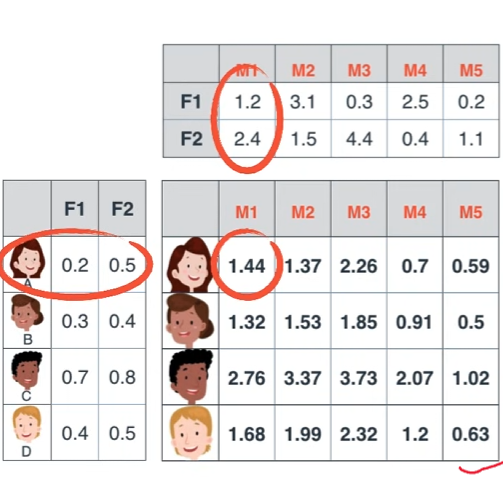

 FOR EVERY RATING WE DO:-

1. Take user's latent vector
2. Take movie's latent vector
3. Dot product → prediction
4. Compare with actual rating
5. Calculate loss
6. Update the vectors

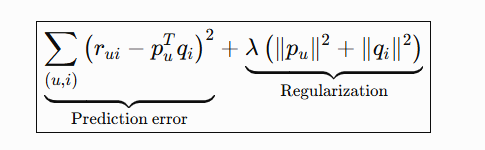

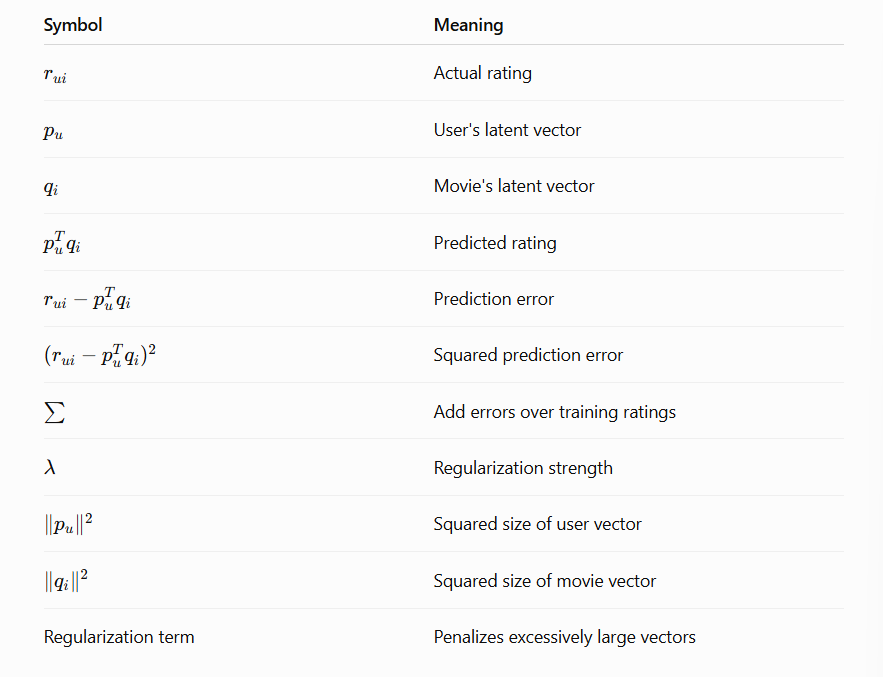


λ is known as Regularization strength, It is an hyperparemeter that controls how strongly we penalize large-vector values

Why do we need Regularization?
->  Our model could make up values extremly large or extremly small, whose   dot product is valid, Ex:- [100,100]⋅[0.05,0.05]
We dont want the learned vectors becoming unnecessarily huge




Gradient descent

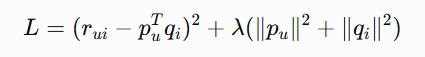
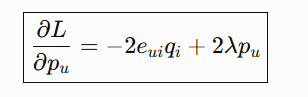
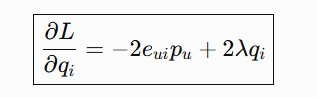

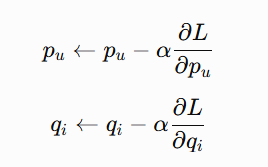


## B) Model-Based Collaborative Filtering — Matrix Factorization

Matrix factorization represents each user and each movie using a small number of learned latent factors.

The dot product between a user's latent vector and a movie's latent vector gives the predicted rating.

We learn these latent vectors using gradient descent.

In [ ]:
# RUNNING Model-Based Collaborative Filtering — Matrix Factorization
# on a tiny toy dataset



# STEP 1:-  Create a tiny dataset

import numpy as np
ratings = np.array([
    [5, 3, np.nan, 4],
    [4, np.nan, 2, 5],
    [np.nan, 4, 5, np.nan]
])
print("-------------------------------------------")

# STEP 2:- Create Two matrices 1) users*factors 2) Movies*factors

n_users = ratings.shape[0]
n_movies = ratings.shape[1]
k = 2   # number of latent factors # Every user will be represented by 2 numbers, and every movie will also be represented by 2 numbers.
print("Number of users:", n_users)
print("Number of movies:", n_movies)
print("Number of latent factors:", k)
np.random.seed(42)
P = np.random.rand(n_users, k)
Q = np.random.rand(n_movies, k)
print("User matrix P:")
print(P)
print("\nMovie matrix Q:")
print(Q)
print("-------------------------------------------")

# Step 3:- Doing prediction of rating By first user on first movie

user_id = 0
movie_id = 0
prediction = np.dot(P[user_id], Q[movie_id])
print("Predicted rating:", prediction)
print("Actual rating:", ratings[user_id, movie_id])
print("-------------------------------------------")

# Step 4:- Finding error:-

actual = ratings[user_id, movie_id]
error = actual - prediction
print("Actual rating:", actual)
print("Predicted rating:", prediction)
print("Error:", error)
print("-------------------------------------------")

# Step 5:- Turning Error into loss

loss = error ** 2
print("Error:", error)
print("Squared error (loss):", loss)
print("-------------------------------------------")

# Step 6:- Gradient Descent

user_gradient = -2 * error * Q[movie_id]
print("User gradient:", user_gradient)

movie_gradient = -2 * error * P[user_id]
print("Movie gradient:", movie_gradient)

learning_rate = 0.01

P[user_id] = P[user_id] - learning_rate * user_gradient
Q[movie_id] = Q[movie_id] - learning_rate * movie_gradient
print("-------------------------------------------")

# Step 7:- Doing perdiction again on updates latent Vectors

new_prediction = np.dot(P[user_id], Q[movie_id])
new_error = actual - new_prediction
new_loss = new_error ** 2
print("New predicted rating:", new_prediction)
print("Actual rating:", actual)
print("New error:", new_error)
print("New loss:", new_loss)
print("-------------------------------------------")

# Step 8:-  We keep on doing this until we achive minimum Error or epochs are over


-------------------------------------------
Number of users: 3
Number of movies: 4
Number of latent factors: 2
User matrix P:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]]

Movie matrix Q:
[[0.05808361 0.86617615]
 [0.60111501 0.70807258]
 [0.02058449 0.96990985]
 [0.83244264 0.21233911]]
-------------------------------------------
Predicted rating: 0.8452406966637934
Actual rating: 5.0
-------------------------------------------
Actual rating: 5.0
Predicted rating: 0.8452406966637934
Error: 4.154759303336206
-------------------------------------------
Error: 4.154759303336206
Squared error (loss): 17.26202486865876
-------------------------------------------
User gradient: [-0.48264686 -7.1975068 ]
Movie gradient: [-3.11224809 -7.89997822]
-------------------------------------------
New predicted rating: 1.0004631895649083
Actual rating: 5.0
New error: 3.9995368104350915
New loss: 15.996294698025304
-------------------------------------------


                 EPOCH 1
                    ↓
       ┌─────────────────────────┐
       │ Process 79,619 ratings  │
       │                         │
       │ prediction             │
       │ error                  │
       │ gradient               │
       │ update P and Q         │
       │                         │
       │ ...                     │
       └─────────────────────────┘
                    ↓
              EPOCH 1 DONE
                    ↓
                 EPOCH 2
                    ↓
       ┌─────────────────────────┐
       │ Process 79,619 ratings  │
       └─────────────────────────┘
                    ↓
                  ...

### OK Now Starting with actual dataset and actual code

In [92]:
# Matrix Factorization - MovieLens

import numpy as np
import pandas as pd

# Use the train dataframe we created earlier
mf_train = train[["user_id", "item_id", "ratings"]].copy()

# Convert IDs to zero-based indices
user_ids = mf_train["user_id"].unique()
item_ids = mf_train["item_id"].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

mf_train["user_idx"] = mf_train["user_id"].map(user_to_idx)
mf_train["item_idx"] = mf_train["item_id"].map(item_to_idx)

n_users = len(user_ids)
n_items = len(item_ids)

print("Users:", n_users)
print("Movies:", n_items)
print("Training ratings:", len(mf_train))

Users: 943
Movies: 1650
Training ratings: 79619


In [93]:
# Number of latent factors
k = 20

# Hyperparameters
learning_rate = 0.005
regularization = 0.02
epochs = 20

# Random initialization
np.random.seed(42)

P = np.random.normal(
    0,
    0.1,
    size=(n_users, k)
)

Q = np.random.normal(
    0,
    0.1,
    size=(n_items, k)
)

print("P shape:", P.shape)
print("Q shape:", Q.shape)

P shape: (943, 20)
Q shape: (1650, 20)


In [94]:
loss_history = []

for epoch in range(epochs):

    total_loss = 0.0

    # Shuffle training ratings
    shuffled_train = mf_train.sample(frac=1, random_state=epoch)

    for _, row in shuffled_train.iterrows():

        u = row["user_idx"]
        i = row["item_idx"]
        actual = row["ratings"]

        # Current user and movie vectors
        user_vector = P[u]
        item_vector = Q[i]

        # Prediction
        prediction = np.dot(user_vector, item_vector)

        # Error
        error = actual - prediction

        # Gradients
        user_gradient = -2 * error * item_vector + 2 * regularization * user_vector
        item_gradient = -2 * error * user_vector + 2 * regularization * item_vector

        # Update
        P[u] -= learning_rate * user_gradient
        Q[i] -= learning_rate * item_gradient

        # Add loss
        total_loss += error ** 2

    average_loss = total_loss / len(mf_train)
    loss_history.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Training MSE: {average_loss:.4f}"
    )

Epoch 1/20 - Training MSE: 12.5220
Epoch 2/20 - Training MSE: 2.9469
Epoch 3/20 - Training MSE: 1.2698
Epoch 4/20 - Training MSE: 1.0234
Epoch 5/20 - Training MSE: 0.9346
Epoch 6/20 - Training MSE: 0.8850
Epoch 7/20 - Training MSE: 0.8467
Epoch 8/20 - Training MSE: 0.8136
Epoch 9/20 - Training MSE: 0.7822
Epoch 10/20 - Training MSE: 0.7525
Epoch 11/20 - Training MSE: 0.7232
Epoch 12/20 - Training MSE: 0.6963
Epoch 13/20 - Training MSE: 0.6697
Epoch 14/20 - Training MSE: 0.6453
Epoch 15/20 - Training MSE: 0.6214
Epoch 16/20 - Training MSE: 0.6000
Epoch 17/20 - Training MSE: 0.5795
Epoch 18/20 - Training MSE: 0.5617
Epoch 19/20 - Training MSE: 0.5444
Epoch 20/20 - Training MSE: 0.5294


### Predict the test ratings



In [42]:
actuals = []
predictions = []

for _, row in test.iterrows():

    user_id = row["user_id"]
    item_id = row["item_id"]

    # Convert original IDs to our matrix indices
    u = user_to_idx[user_id]
    i = item_to_idx[item_id]

    # Predict using learned vectors
    prediction = np.dot(P[u], Q[i])

    actuals.append(row["ratings"])
    predictions.append(prediction)

actuals = np.array(actuals)
predictions = np.array(predictions)

print("Test predictions:", len(predictions))
print("Test ratings:", len(actuals))

Test predictions: 20350
Test ratings: 20350


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actuals, predictions)

rmse = np.sqrt(
    mean_squared_error(actuals, predictions)
)

print("Matrix Factorization MAE:", mae)
print("Matrix Factorization RMSE:", rmse)

Matrix Factorization MAE: 0.7465220649795521
Matrix Factorization RMSE: 0.952546470821247


## Fair Comparison between Memory based approach and Matrix Factorization based approach on Common Test Cases

The memory-based approach cannot make predictions for every test interaction because some users do not have enough similar neighbors who rated the target movie.

To compare prediction accuracy fairly, we evaluate both approaches on the same test interactions for which the memory-based method produced a prediction.

We also report coverage separately, since the ability to produce predictions for a larger portion of the test set is itself an important property of a recommender system.

In [96]:
# Matrix Factorization predictions on the same cases
# that Memory-Based CF was able to predict

mf_common_predictions = []
common_actuals = []

for user_id, item_id in evaluated_cases:

    u = user_to_idx[user_id]
    i = item_to_idx[item_id]

    prediction = np.dot(P[u], Q[i])

    mf_common_predictions.append(prediction)

    # Get the actual rating from the test set
    actual = test[
        (test["user_id"] == user_id) &
        (test["item_id"] == item_id)
    ]["ratings"].iloc[0]

    common_actuals.append(actual)

mf_common_predictions = np.array(mf_common_predictions)
common_actuals = np.array(common_actuals)

print("Common test cases:", len(common_actuals))

Common test cases: 13596


In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Memory-Based CF on the common test cases
memory_mae = mean_absolute_error(
    memory_actuals,
    memory_predictions
)

memory_rmse = np.sqrt(
    mean_squared_error(
        memory_actuals,
        memory_predictions
    )
)

# Matrix Factorization on the exact same test cases
mf_common_mae = mean_absolute_error(
    common_actuals,
    mf_common_predictions
)

mf_common_rmse = np.sqrt(
    mean_squared_error(
        common_actuals,
        mf_common_predictions
    )
)

print("Memory-Based CF")
print("MAE:", memory_mae)
print("RMSE:", memory_rmse)

print("\nMatrix Factorization")
print("MAE:", mf_common_mae)
print("RMSE:", mf_common_rmse)

Memory-Based CF
MAE: 0.8562429669847376
RMSE: 1.1212343203391641

Matrix Factorization
MAE: 0.7208159774675998
RMSE: 0.916128880607007


## 9. Results Comparison

Both methods are evaluated on the same 13,923 test interactions for which the memory-based approach was able to generate a prediction.

Coverage is reported separately because the memory-based approach cannot always generate a prediction when no suitable neighbor has rated the target movie.

In [98]:
results = pd.DataFrame({
    "Model": [
        "Memory-Based CF",
        "Matrix Factorization"
    ],
    "MAE": [
        memory_mae,
        mf_common_mae
    ],
    "RMSE": [
        memory_rmse,
        mf_common_rmse
    ],
    "Coverage": [
        len(memory_predictions) / len(test),
        1.0
    ]
})

results

,Model,MAE,RMSE,Coverage
0,Memory-Based CF,0.856243,1.121234,0.668239
1,Matrix Factorization,0.720816,0.916129,1.000000


## 10. Model Comparison Plot

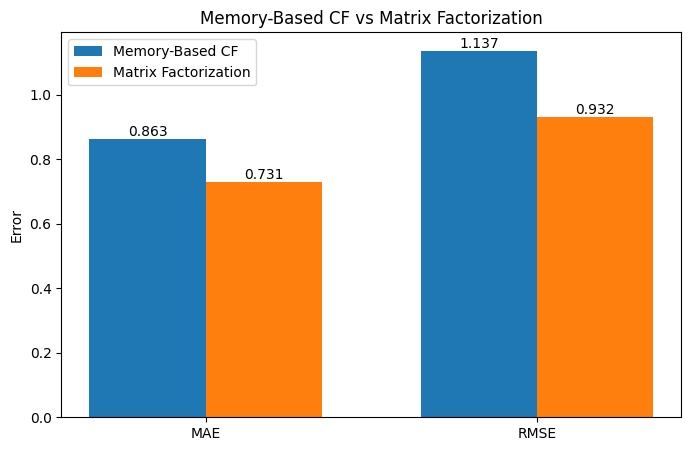

In [99]:
plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width / 2,
    memory_scores,
    width,
    label="Memory-Based CF"
)

bars2 = plt.bar(
    x + width / 2,
    mf_scores,
    width,
    label="Matrix Factorization"
)

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("Memory-Based CF vs Matrix Factorization")
plt.legend()

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

plt.show()

## 11. Matrix Factorization Training Loss

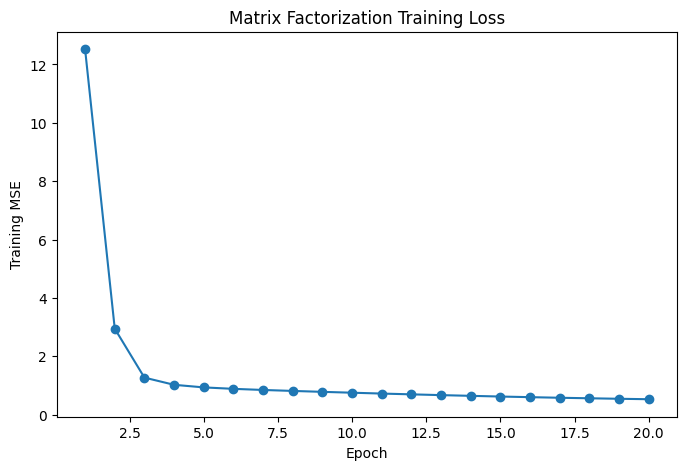

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Matrix Factorization Training Loss")

plt.show()

## 12. Conclusion

The two collaborative filtering approaches were evaluated using the same MovieLens dataset and the same train/test split.

Memory-Based Collaborative Filtering calculates similarities between users and uses ratings from similar users to make predictions. In our experiment, it achieved a coverage of 68.42%, meaning it could generate predictions for 13,923 out of 20,350 test interactions.

Matrix Factorization learned compact latent representations for users and movies using gradient descent. It achieved 100% coverage on the test set.

For a fair accuracy comparison, both methods were evaluated on the same 13,923 test interactions:

| Model | MAE | RMSE | Coverage |
|---|---:|---:|---:|
| Memory-Based CF | 0.8627 | 1.1369 | 68.42% |
| Matrix Factorization | 0.7308 | 0.9321 | 100% |

On these common test cases, Matrix Factorization produced lower MAE and RMSE than the Memory-Based approach. It also generated predictions for all test interactions.

Memory-Based Collaborative Filtering is useful when recommendations based directly on similar users are desirable and the neighborhood relationships themselves are important. However, its ability to make predictions can be limited when suitable neighbors have not rated an item.

Matrix Factorization is useful when the interaction matrix is sparse and a compact representation of users and items is desirable. In this experiment, the learned latent representations allowed it to make predictions across the complete test set.

Overall, the experiment demonstrates the difference between neighborhood-based collaborative filtering and model-based collaborative filtering, and shows how matrix factorization can learn latent user-item relationships rather than relying directly on explicit user neighborhoods.